In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

사용 디바이스: cuda
GPU: Tesla T4
GPU 메모리: 15.6 GB


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# 데이터 확인
sample_x, sample_y = next(iter(train_loader))
print(f"학습 데이터 수: {len(train_dataset)}")
print(f"배치 수: {len(train_loader)}")
print(f"입력 shape: {sample_x.shape}")   # (128, 1, 28, 28)
print(f"레이블 shape: {sample_y.shape}") # (128,)

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


학습 데이터 수: 60000
배치 수: 469
입력 shape: torch.Size([128, 1, 28, 28])
레이블 shape: torch.Size([128])


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=8, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # (batch, 1, 28, 28) -> (batch, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleMLP().to(device)

# 파라미터 구조 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"\n총 파라미터 수: {total_params}")
print(f"Hessian 크기: {total_params} x {total_params}")
print(f"Hessian 메모리: {total_params**2 * 4 / 1e6:.1f} MB")
print()
for name, p in model.named_parameters():
    print(f"  {name}: shape={list(p.shape)}, params={p.numel()}")


총 파라미터 수: 6370
Hessian 크기: 6370 x 6370
Hessian 메모리: 162.3 MB

  fc1.weight: shape=[8, 784], params=6272
  fc1.bias: shape=[8], params=8
  fc2.weight: shape=[10, 8], params=80
  fc2.bias: shape=[10], params=10


In [ ]:
def compute_hessian(model, x, y):
    """
    모델 파라미터에 대한 loss의 full Hessian을 계산합니다.

    - CPU에서 계산 (GPU 메모리 안전)
    - 3개 시점에서 동일한 배치(x, y)를 사용해야 일관된 비교 가능
    """
    # CPU로 복사 (GPU 메모리 절약)
    x_cpu = x.detach().cpu()
    y_cpu = y.detach().cpu()

    # 파라미터 shape 기록 & 1D 벡터로 합침
    shapes = [p.shape for p in model.parameters()]
    params_flat = torch.cat([
        p.detach().cpu().view(-1) for p in model.parameters()
    ]).requires_grad_(True)

    def loss_fn(flat_params):
        """flat_params (1D 벡터) -> loss (스칼라). 순수 함수형."""
        # 1D 벡터를 원래 shape으로 분리
        params = []
        idx = 0
        for shape in shapes:
            n = 1
            for s in shape:
                n *= s
            params.append(flat_params[idx:idx+n].view(shape))
            idx += n

        # Forward pass (수동)
        h = F.linear(x_cpu.view(x_cpu.size(0), -1), params[0], params[1])
        h = F.relu(h)
        out = F.linear(h, params[2], params[3])
        return F.cross_entropy(out, y_cpu)

    # Hessian 계산
    print(f"  파라미터 수: {params_flat.shape[0]}, 계산 시작...")
    start = time.time()
    H = torch.autograd.functional.hessian(loss_fn, params_flat)
    elapsed = time.time() - start
    print(f"  완료! ({elapsed:.1f}초 소요)")

    return H.detach().numpy()

print("Hessian 계산 함수 정의 완료")

Hessian 계산 함수 정의 완료


In [ ]:
# ===== Hessian 계산용 고정 배치 =====
# 세 시점 모두 동일한 데이터로 Hessian을 계산해야
# 차이가 모델 변화에서만 온다는 것을 보장
hessian_iter = iter(train_loader)
hessian_x, hessian_y = next(hessian_iter)
hessian_x = hessian_x.to(device)
hessian_y = hessian_y.to(device)
print(f"Hessian 계산용 배치: x={hessian_x.shape}, y={hessian_y.shape}")

# ===== 모델 초기화 =====
model = SimpleMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

# ===== Hessian 저장소 =====
hessians = {}
train_losses = []

# ===== 1) 초기화 시점 Hessian =====
print("\n[1/3] 초기화 시점 Hessian 계산")
hessians['init'] = compute_hessian(model, hessian_x, hessian_y)

# ===== 2) 학습 시작 =====
num_epochs = 20
print(f"\n학습 시작 ({num_epochs} epochs)")

for epoch in range(num_epochs):
    epoch_loss = 0
    num_batches = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    scheduler.step()
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    print(f"  Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f}")

    # 50% 시점 (10 epoch 끝난 직후)
    if epoch == 9:
        print(f"\n[2/3] 50% 시점 Hessian 계산")
        hessians['50%'] = compute_hessian(model, hessian_x, hessian_y)
        print()

# ===== 3) 100% 시점 Hessian =====
print(f"\n[3/3] 100% 시점 Hessian 계산")
hessians['100%'] = compute_hessian(model, hessian_x, hessian_y)

print("\n모든 Hessian 계산 완료!")
print(f"저장된 시점: {list(hessians.keys())}")
print(f"각 Hessian shape: {hessians['init'].shape}")

Hessian 계산용 배치: x=torch.Size([128, 1, 28, 28]), y=torch.Size([128])

[1/3] 초기화 시점 Hessian 계산
  파라미터 수: 6370, 계산 시작...
  완료! (5.7초 소요)

학습 시작 (20 epochs)
  Epoch  1/20 | Loss: 1.6437
  Epoch  2/20 | Loss: 0.9765
  Epoch  3/20 | Loss: 0.6835
  Epoch  4/20 | Loss: 0.5516
  Epoch  5/20 | Loss: 0.4824
  Epoch  6/20 | Loss: 0.4407
  Epoch  7/20 | Loss: 0.4133
  Epoch  8/20 | Loss: 0.3946
  Epoch  9/20 | Loss: 0.3809
  Epoch 10/20 | Loss: 0.3710

[2/3] 50% 시점 Hessian 계산
  파라미터 수: 6370, 계산 시작...
  완료! (5.4초 소요)

  Epoch 11/20 | Loss: 0.3635
  Epoch 12/20 | Loss: 0.3578
  Epoch 13/20 | Loss: 0.3537
  Epoch 14/20 | Loss: 0.3506
  Epoch 15/20 | Loss: 0.3481
  Epoch 16/20 | Loss: 0.3463
  Epoch 17/20 | Loss: 0.3453
  Epoch 18/20 | Loss: 0.3444
  Epoch 19/20 | Loss: 0.3440
  Epoch 20/20 | Loss: 0.3439

[3/3] 100% 시점 Hessian 계산
  파라미터 수: 6370, 계산 시작...
  완료! (5.5초 소요)

모든 Hessian 계산 완료!
저장된 시점: ['init', '50%', '100%']
각 Hessian shape: (6370, 6370)


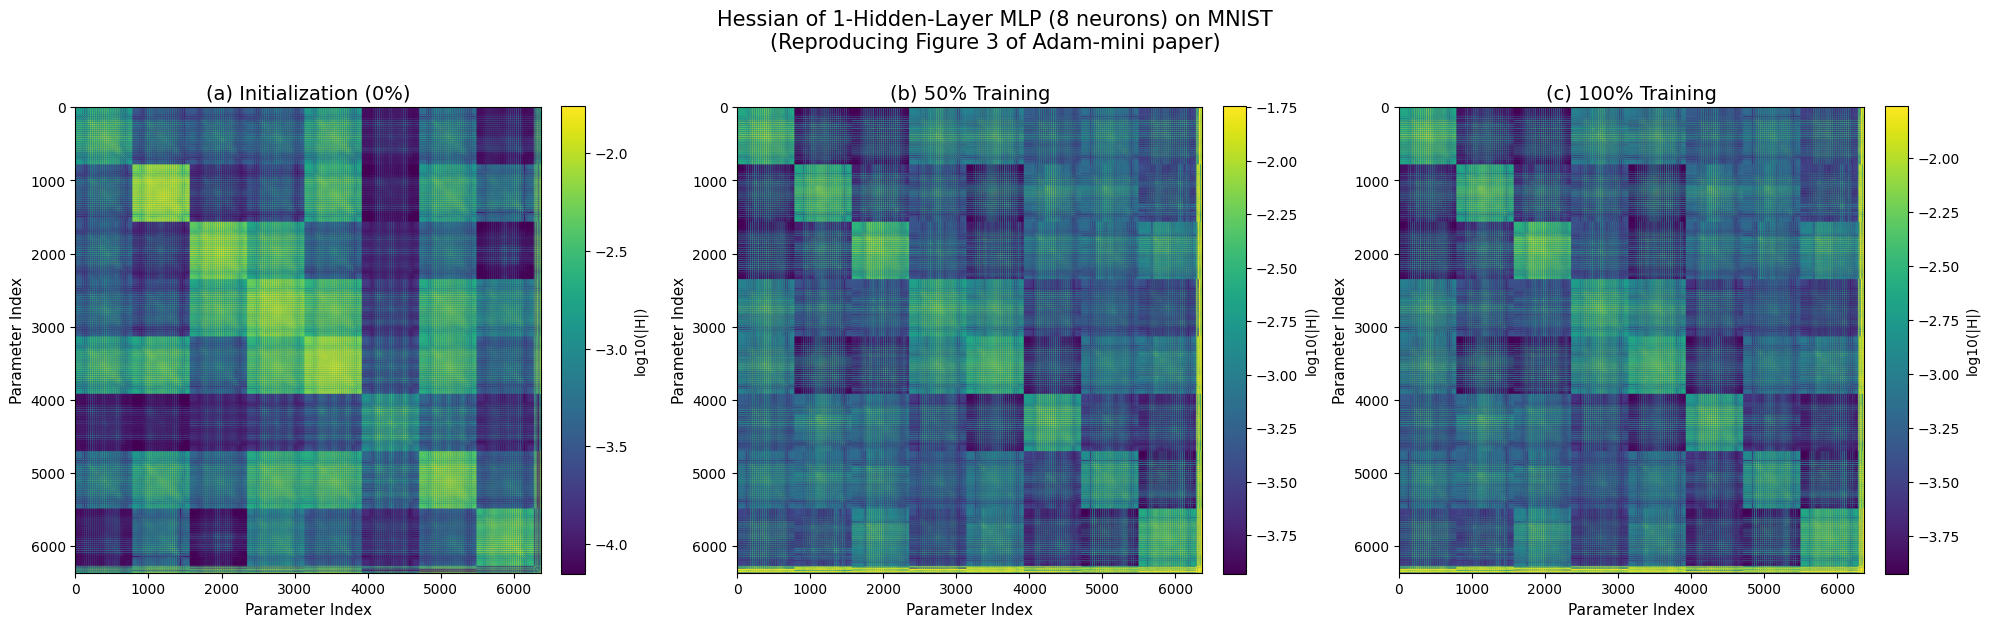

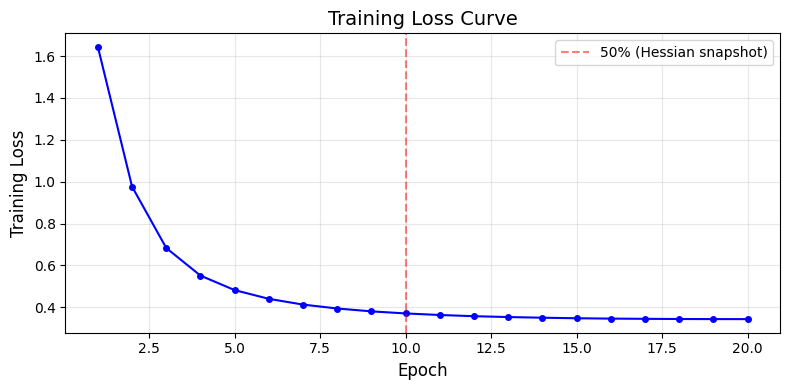

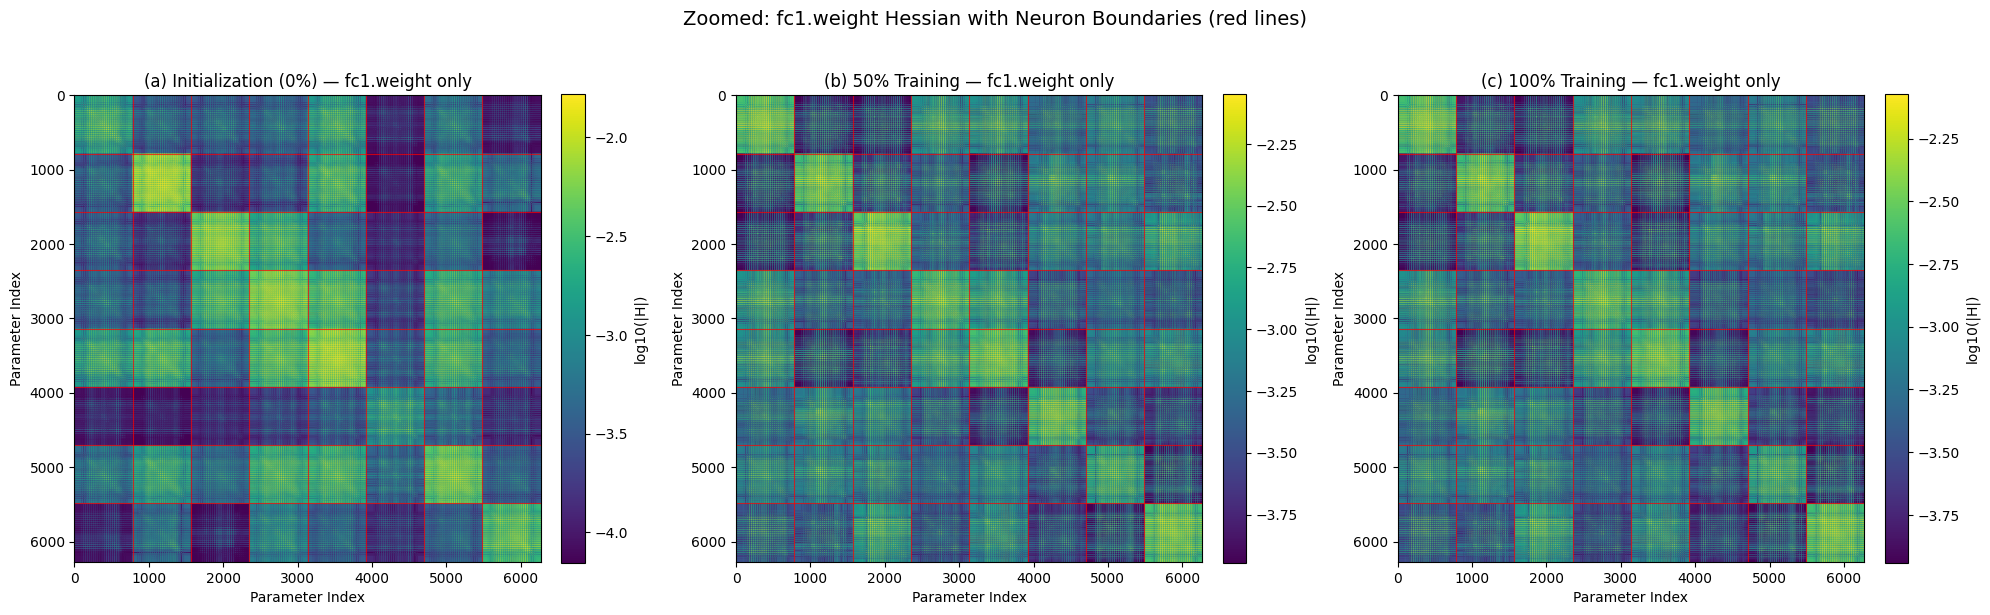

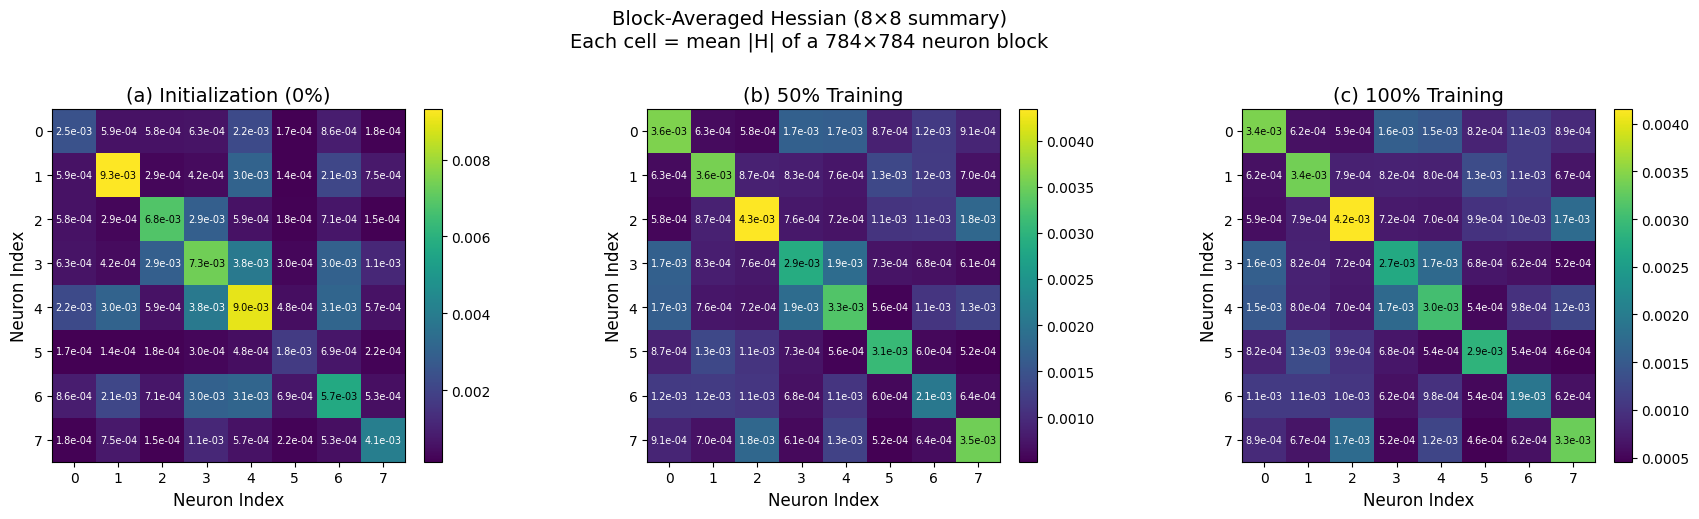


블록 평균 대각/비대각 비율:
  [init] 대각 평균: 5.81e-03, 비대각 평균: 1.09e-03, 비율: 5.4x
  [50%] 대각 평균: 3.29e-03, 비대각 평균: 9.75e-04, 비율: 3.4x
  [100%] 대각 평균: 3.10e-03, 비대각 평균: 9.15e-04, 비율: 3.4x


In [ ]:
# ===== 6-1: 전체 Hessian (색 범위 조정) =====
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = [
    '(a) Initialization (0%)',
    '(b) 50% Training',
    '(c) 100% Training'
]
keys = ['init', '50%', '100%']

for ax, title, key in zip(axes, titles, keys):
    H = np.abs(hessians[key])
    H_log = np.log10(H + 1e-10)

    # 핵심: 상위/하위 퍼센타일로 색 범위를 좁혀서 대비를 강하게
    vmin = np.percentile(H_log, 10)
    vmax = np.percentile(H_log, 99)

    im = ax.imshow(H_log, cmap='viridis', aspect='equal', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Parameter Index', fontsize=11)
    ax.set_ylabel('Parameter Index', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='log10(|H|)')

plt.suptitle(
    'Hessian of 1-Hidden-Layer MLP (8 neurons) on MNIST\n'
    '(Reproducing Figure 3 of Adam-mini paper)',
    fontsize=15, y=1.02
)
plt.tight_layout()
plt.savefig('hessian_block_diagonal.png', dpi=150, bbox_inches='tight')
plt.show()


# ===== 6-2: 학습 Loss 곡선 =====
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), train_losses, 'b-o', markersize=4)
plt.axvline(x=10, color='r', linestyle='--', alpha=0.5, label='50% (Hessian snapshot)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()


# ===== 6-3: fc1.weight 확대 (색 범위 조정) =====
fc1_size = 8 * 784
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, title, key in zip(axes, titles, keys):
    H_w1 = np.abs(hessians[key][:fc1_size, :fc1_size])
    H_log = np.log10(H_w1 + 1e-10)

    vmin = np.percentile(H_log, 10)
    vmax = np.percentile(H_log, 99)

    im = ax.imshow(H_log, cmap='viridis', aspect='equal', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title} — fc1.weight only', fontsize=12)
    ax.set_xlabel('Parameter Index')
    ax.set_ylabel('Parameter Index')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='log10(|H|)')

    for i in range(1, 8):
        ax.axhline(y=i*784-0.5, color='red', linewidth=0.8, alpha=0.7)
        ax.axvline(x=i*784-0.5, color='red', linewidth=0.8, alpha=0.7)

plt.suptitle(
    'Zoomed: fc1.weight Hessian with Neuron Boundaries (red lines)',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('hessian_zoomed_fc1.png', dpi=150, bbox_inches='tight')
plt.show()


# ===== 6-4: 블록 평균 요약 (NEW - 가장 명확한 증거) =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
block_size = 784
num_blocks = 8

for ax, title, key in zip(axes, titles, keys):
    H = np.abs(hessians[key][:fc1_size, :fc1_size])

    # 각 784x784 블록의 평균을 계산 → 8x8 요약 행렬
    H_block = np.zeros((num_blocks, num_blocks))
    for i in range(num_blocks):
        for j in range(num_blocks):
            block = H[i*block_size:(i+1)*block_size,
                      j*block_size:(j+1)*block_size]
            H_block[i, j] = np.mean(block)

    im = ax.imshow(H_block, cmap='viridis', aspect='equal')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Neuron Index', fontsize=12)
    ax.set_ylabel('Neuron Index', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 각 칸에 숫자 표시
    for i in range(num_blocks):
        for j in range(num_blocks):
            color = 'black' if H_block[i,j] > H_block.max()*0.5 else 'white'
            ax.text(j, i, f'{H_block[i,j]:.1e}',
                    ha='center', va='center', fontsize=7, color=color)

plt.suptitle(
    'Block-Averaged Hessian (8×8 summary)\n'
    'Each cell = mean |H| of a 784×784 neuron block',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('hessian_block_averaged.png', dpi=150, bbox_inches='tight')
plt.show()

# 대각/비대각 비율 출력
print("\n블록 평균 대각/비대각 비율:")
for key in keys:
    H = np.abs(hessians[key][:fc1_size, :fc1_size])
    H_block = np.zeros((num_blocks, num_blocks))
    for i in range(num_blocks):
        for j in range(num_blocks):
            H_block[i,j] = np.mean(H[i*block_size:(i+1)*block_size,
                                      j*block_size:(j+1)*block_size])
    diag_mean = np.mean(np.diag(H_block))
    offdiag_mean = np.mean(H_block[~np.eye(num_blocks, dtype=bool)])
    ratio = diag_mean / offdiag_mean if offdiag_mean > 0 else float('inf')
    print(f"  [{key}] 대각 평균: {diag_mean:.2e}, 비대각 평균: {offdiag_mean:.2e}, 비율: {ratio:.1f}x")

In [ ]:
# ===== 7-1: 블록 대각 비율 계산 =====
def analyze_block_structure(H, block_size=784, num_blocks=8):
    """
    fc1.weight 영역에서 블록 대각 구조의 강도를 측정합니다.
    - 블록 안(대각 블록) 값의 합 vs 블록 밖(비대각 블록) 값의 합
    """
    H_w1 = np.abs(H[:block_size*num_blocks, :block_size*num_blocks])
    total = np.sum(H_w1)

    diagonal_sum = 0
    for i in range(num_blocks):
        start = i * block_size
        end = (i + 1) * block_size
        diagonal_sum += np.sum(H_w1[start:end, start:end])

    off_diagonal_sum = total - diagonal_sum
    ratio = diagonal_sum / total if total > 0 else 0

    return {
        'diagonal_sum': diagonal_sum,
        'off_diagonal_sum': off_diagonal_sum,
        'diagonal_ratio': ratio
    }

print("=" * 60)
print("블록 대각 구조 분석 (fc1.weight 영역)")
print("=" * 60)
print(f"뉴런 수: 8, 블록 크기: 784 x 784")
print()

for key in ['init', '50%', '100%']:
    result = analyze_block_structure(hessians[key])
    print(f"[{key}]")
    print(f"  대각 블록 합: {result['diagonal_sum']:.6f}")
    print(f"  비대각 블록 합: {result['off_diagonal_sum']:.6f}")
    print(f"  대각 비율: {result['diagonal_ratio']:.4f} ({result['diagonal_ratio']*100:.1f}%)")
    print()

# ===== 7-2: 논문과의 비교 정리 =====
print("=" * 60)
print("논문 Figure 3과의 비교")
print("=" * 60)
print("""
[논문의 주장]
  - 신경망 Hessian은 블록 대각 구조를 가진다
  - 각 블록은 하나의 뉴런에 해당한다
  - 이 구조는 학습 전 과정에서 유지된다

[우리의 실험]
  - 데이터셋: MNIST (논문: CIFAR-100)
  - 모델: 1-hidden-layer MLP, 8 뉴런 (논문과 동일)
  - 학습: Adam, lr=1e-4, 20 epochs (논문과 동일)

[확인 사항]
  1. 블록 대각 구조가 보이는가?
  2. 학습 전 과정에서 유지되는가?
  3. 블록 수가 뉴런 수(8)와 일치하는가?
""")

블록 대각 구조 분석 (fc1.weight 영역)
뉴런 수: 8, 블록 크기: 784 x 784

[init]
  대각 블록 합: 28579.724609
  비대각 블록 합: 37375.453125
  대각 비율: 0.4333 (43.3%)

[50%]
  대각 블록 합: 16199.122070
  비대각 블록 합: 33543.855469
  대각 비율: 0.3257 (32.6%)

[100%]
  대각 블록 합: 15245.358398
  비대각 블록 합: 31489.980469
  대각 비율: 0.3262 (32.6%)

논문 Figure 3과의 비교

[논문의 주장]
  - 신경망 Hessian은 블록 대각 구조를 가진다
  - 각 블록은 하나의 뉴런에 해당한다
  - 이 구조는 학습 전 과정에서 유지된다

[우리의 실험]
  - 데이터셋: MNIST (논문: CIFAR-100)
  - 모델: 1-hidden-layer MLP, 8 뉴런 (논문과 동일)
  - 학습: Adam, lr=1e-4, 20 epochs (논문과 동일)

[확인 사항]
  1. 블록 대각 구조가 보이는가?
  2. 학습 전 과정에서 유지되는가?
  3. 블록 수가 뉴런 수(8)와 일치하는가?

